<a href="https://colab.research.google.com/github/dineshkarthikmcse2025-hue/DAA-EXPT/blob/main/DAA%20EXP9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Items : [0.5, 0.7, 0.3, 0.9, 0.2, 0.6, 0.8, 0.4, 0.1, 0.5]
Capacity : 1.0
Total Weight : 5.0
Lower Bound : 5

First Fit (FF): 6 bins
Bin 1: [0.5, 0.3, 0.2]  Used=1.0 [####################]
Bin 2: [0.7, 0.1]  Used=0.8 [###############     ]
Bin 3: [0.9]  Used=0.9 [##################  ]
Bin 4: [0.6, 0.4]  Used=1.0 [####################]
Bin 5: [0.8]  Used=0.8 [################    ]
Bin 6: [0.5]  Used=0.5 [##########          ]

First Fit Decreasing (FFD): 6 bins
Bin 1: [0.9]  Used=0.9 [##################  ]
Bin 2: [0.8, 0.1]  Used=0.9 [##################  ]
Bin 3: [0.7, 0.3]  Used=1.0 [####################]
Bin 4: [0.6, 0.4]  Used=1.0 [####################]
Bin 5: [0.5, 0.5]  Used=1.0 [####################]
Bin 6: [0.2]  Used=0.2 [####                ]

Best Fit Decreasing (BFD): 6 bins
Bin 1: [0.9]  Used=0.9 [##################  ]
Bin 2: [0.8, 0.1]  Used=0.9 [##################  ]
Bin 3: [0.7, 0.3]  Used=1.0 [####################]
Bin 4: [0.6, 0.4]  Used=1.0 [####################]
Bin 5

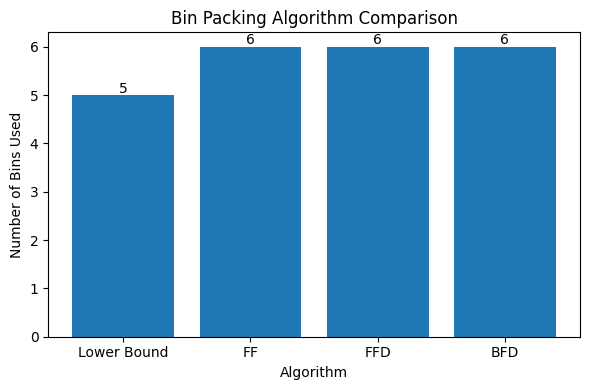

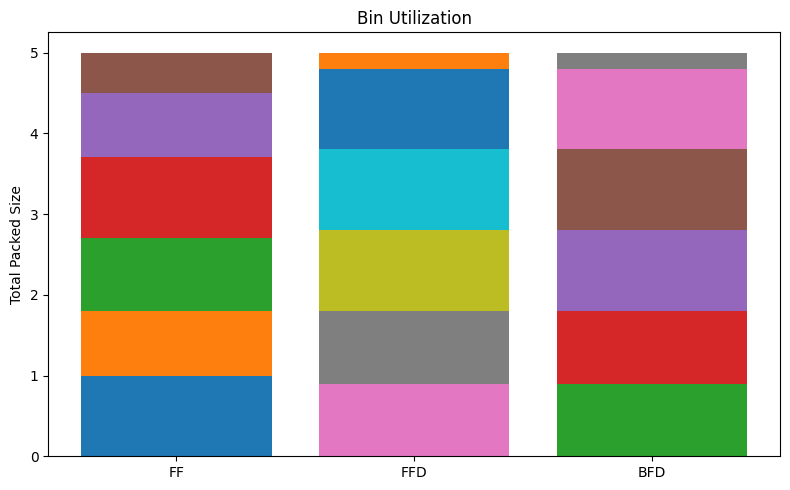

In [1]:
import matplotlib.pyplot as plt

def first_fit(items, capacity=1.0):
    bins = []
    bin_contents = []

    for item in items:
        placed = False

        for i, space in enumerate(bins):
            if space >= item:
                bins[i] -= item
                bin_contents[i].append(item)
                placed = True
                break

        if not placed:
            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents


def first_fit_decreasing(items, capacity=1.0):
    return first_fit(sorted(items, reverse=True), capacity)


def best_fit_decreasing(items, capacity=1.0):
    items = sorted(items, reverse=True)

    bins = []
    bin_contents = []

    for item in items:
        best_index = -1
        best_space = float("inf")

        for i, space in enumerate(bins):
            if space >= item and (space - item) < best_space:
                best_space = space - item
                best_index = i

        if best_index != -1:
            bins[best_index] -= item
            bin_contents[best_index].append(item)
        else:
            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents


def display_bins(title, bins):
    print(f"\n{title}: {len(bins)} bins")

    for i, b in enumerate(bins, 1):
        used = sum(b)
        bar = "#" * int(used * 20)
        print(f"Bin {i}: {b}  Used={used:.1f} [{bar:<20}]")


# ---------------- Main ----------------

items = [0.5, 0.7, 0.3, 0.9, 0.2, 0.6, 0.8, 0.4, 0.1, 0.5]
capacity = 1.0

lower_bound = int(-(-sum(items) // capacity))

print("Items :", items)
print("Capacity :", capacity)
print("Total Weight :", sum(items))
print("Lower Bound :", lower_bound)

ff_bins = first_fit(items)
ffd_bins = first_fit_decreasing(items)
bfd_bins = best_fit_decreasing(items)

display_bins("First Fit (FF)", ff_bins)
display_bins("First Fit Decreasing (FFD)", ffd_bins)
display_bins("Best Fit Decreasing (BFD)", bfd_bins)

print("\nSummary")
print("Lower Bound =", lower_bound)
print("FF =", len(ff_bins))
print("FFD =", len(ffd_bins))
print("BFD =", len(bfd_bins))

# ==========================================================
# GRAPH 1 : Number of bins comparison
# ==========================================================

algorithms = ["Lower Bound", "FF", "FFD", "BFD"]
values = [lower_bound, len(ff_bins), len(ffd_bins), len(bfd_bins)]

plt.figure(figsize=(6,4))
plt.bar(algorithms, values)

plt.title("Bin Packing Algorithm Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Number of Bins Used")

for i, v in enumerate(values):
    plt.text(i, v + 0.05, str(v), ha="center")

plt.tight_layout()
plt.show()

# ==========================================================
# GRAPH 2 : Bin Utilization (Stacked Bar Chart)
# ==========================================================

plt.figure(figsize=(8,5))

for idx, bins in enumerate([ff_bins, ffd_bins, bfd_bins]):

    bottom = 0

    for b in bins:
        plt.bar(
            ["FF", "FFD", "BFD"][idx],
            sum(b),
            bottom=bottom
        )
        bottom += sum(b)

plt.title("Bin Utilization")
plt.ylabel("Total Packed Size")

plt.tight_layout()
plt.show()